In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [42]:
df_AQ = pd.read_csv("DelhiPollutionData_full_MandirMarg.csv")

In [43]:
df_modi = pd.read_csv("modis_new.csv")

In [57]:
df_wind = pd.read_csv("WindDataNew.csv")
df_wind['valid_time'] = pd.to_datetime(df_wind['valid_time']).dt.tz_localize('UTC').dt.tz_convert('UTC')


In [63]:
delhi_wind = df_wind[
    (df_wind["latitude"] == 28.75) &
    (df_wind["longitude"] == 77.25)
].copy()

delhi_wind["wind_speed"] = np.sqrt(
    delhi_wind["u10"]**2 +
    delhi_wind["v10"]**2
)

delhi_wind["temperature_C"] = (
    delhi_wind["t2m"] - 273.15
)

In [64]:
weather = delhi_wind[
    [
        "valid_time",
        "wind_speed",
        "temperature_C"
    ]
].copy()

weather = weather.rename(
    columns={"valid_time": "datetime"}
)

In [65]:
aq = df_AQ.copy()

aq["datetime"] = pd.to_datetime(aq["datetime"], utc=True)

aq = aq.sort_values("datetime")

pm25 = (
    aq[aq["parameter"] == "pm25"]
    .set_index("datetime")["value"]
    .resample("1h")
    .mean()
    .rename("pm25")
)

pm10 = (
    aq[aq["parameter"] == "pm10"]
    .set_index("datetime")["value"]
    .resample("1h")
    .mean()
    .rename("pm10")
)

aq_hourly = pd.concat(
    [pm25, pm10],
    axis=1
).reset_index()


In [ ]:
wind = df_wind.copy()

wind["time"] = pd.to_datetime(
    wind["time"],
    utc=True
)

In [77]:
station_lat = 28.636429
station_lon = 77.201067

grid_points = df_wind[["latitude", "longitude"]].drop_duplicates().copy()

grid_points["distance"] = (
    (grid_points["latitude"] - station_lat)**2 +
    (grid_points["longitude"] - station_lon)**2
)

print(grid_points.sort_values("distance").head(5))

   latitude  longitude  distance
5     28.75      77.25  0.015293
8     28.50      77.25  0.021007
4     28.75      77.00  0.053326
7     28.50      77.00  0.059041
2     29.00      77.25  0.134578


In [78]:
aq_hourly = aq_hourly.set_index("datetime")

# Only fill SHORT gaps (≤3 consecutive missing hours) — long gaps (like the 1113-hour one) stay NaN
aq_hourly["pm25_filled"] = aq_hourly["pm25"].interpolate(method="time", limit=3, limit_area="inside")
aq_hourly["pm10_filled"] = aq_hourly["pm10"].interpolate(method="time", limit=3, limit_area="inside")

aq_hourly = aq_hourly.reset_index()
print(aq_hourly[["pm25", "pm25_filled"]].isna().sum())

pm25           8982
pm25_filled    6474
dtype: int64


In [79]:
merged = pd.merge(aq_hourly, weather, on="datetime", how="left")
print(merged.shape)
print(merged.isna().sum())

(15353, 9)
datetime            0
pm25             8982
pm10             9023
pm25_missing        0
pm10_missing        0
pm25_filled      6474
pm10_filled      6507
wind_speed          0
temperature_C       0
dtype: int64


In [82]:

df_modi["acq_time_str"] = df_modi["acq_time"].astype(str).str.zfill(4)
df_modi["acq_datetime"] = pd.to_datetime(
    df_modi["acq_date"].astype(str) + df_modi["acq_time_str"],
    format="%Y-%m-%d%H%M",
    utc=True
)

fires = df_modi[df_modi["confidence"] >= 50].copy()
if "type" in fires.columns:
    fires = fires[fires["type"] == 0]


fires = fires[
    (fires["latitude"].between(27.5, 32.5)) &
    (fires["longitude"].between(73.5, 77.5))
]


fires["acq_date_only"] = fires["acq_datetime"].dt.date
daily_fires = fires.groupby("acq_date_only").agg(
    fire_count=("latitude", "count"),
    total_frp=("frp", "sum")
).reset_index()

daily_fires["acq_date_only"] = pd.to_datetime(daily_fires["acq_date_only"], utc=True)
print(daily_fires.shape)
print(daily_fires.head())

(555, 3)
              acq_date_only  fire_count  total_frp
0 2020-09-09 00:00:00+00:00           4       37.7
1 2020-09-10 00:00:00+00:00           2       12.0
2 2020-09-12 00:00:00+00:00           4       33.5
3 2020-09-14 00:00:00+00:00           1       16.5
4 2020-09-16 00:00:00+00:00           1       13.9


(555, 3)
                acq_date_only  fire_count  total_frp
349 2021-11-09 00:00:00+00:00        1813    32816.7
347 2021-11-07 00:00:00+00:00        1748    34776.1
55  2020-11-06 00:00:00+00:00        1457    25874.5
53  2020-11-04 00:00:00+00:00        1344    27271.8
340 2021-10-31 00:00:00+00:00        1342    19161.2
342 2021-11-02 00:00:00+00:00        1197    22807.9
48  2020-10-30 00:00:00+00:00        1194    20746.6
46  2020-10-28 00:00:00+00:00        1055    15774.4
62  2020-11-13 00:00:00+00:00         963    13077.1
351 2021-11-11 00:00:00+00:00         957    18851.9


<Axes: xlabel='acq_date_only'>

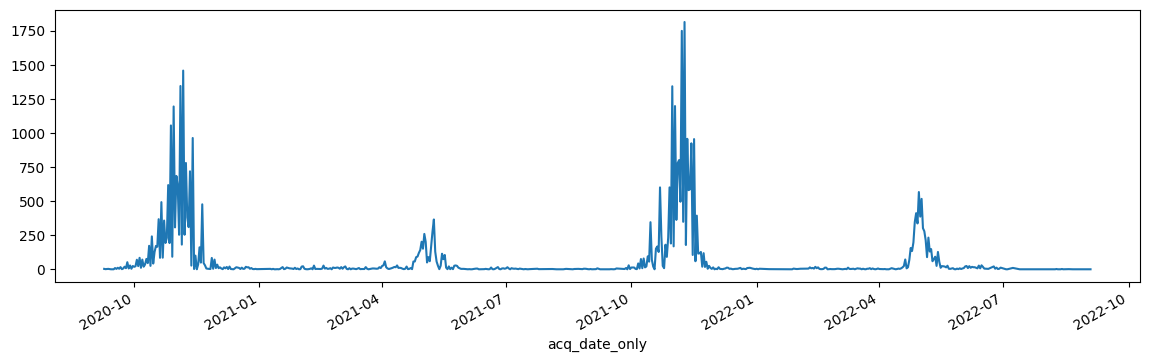

In [84]:
print(daily_fires.shape)
print(daily_fires.sort_values("fire_count", ascending=False).head(10))

daily_fires.set_index("acq_date_only")["fire_count"].plot(figsize=(14,4))

In [85]:
daily_fires = daily_fires.set_index("acq_date_only").sort_index()
daily_fires = daily_fires.asfreq("D", fill_value=0)

daily_fires["fires_last_24h"] = daily_fires["fire_count"].shift(1).rolling(1).sum()
daily_fires["fires_last_48h"] = daily_fires["fire_count"].shift(1).rolling(2).sum()
daily_fires["fires_last_72h"] = daily_fires["fire_count"].shift(1).rolling(3).sum()

daily_fires["frp_last_24h"] = daily_fires["total_frp"].shift(1).rolling(1).sum()
daily_fires["frp_last_48h"] = daily_fires["total_frp"].shift(1).rolling(2).sum()
daily_fires["frp_last_72h"] = daily_fires["total_frp"].shift(1).rolling(3).sum()

daily_fires = daily_fires.reset_index().rename(columns={"acq_date_only": "date"})

In [86]:
merged["date"] = merged["datetime"].dt.date
daily_fires["date"] = pd.to_datetime(daily_fires["date"]).dt.date

fire_cols = ["date", "fires_last_24h", "fires_last_48h", "fires_last_72h",
             "frp_last_24h", "frp_last_48h", "frp_last_72h"]

merged = pd.merge(merged, daily_fires[fire_cols], on="date", how="left")

print(merged.shape)
print(merged[fire_cols[1:]].isna().sum())

(15353, 16)
fires_last_24h    118
fires_last_48h    142
fires_last_72h    166
frp_last_24h      118
frp_last_48h      142
frp_last_72h      166
dtype: int64


In [ ]:
'''Claude's Plan'''

for lag in [1, 2, 3, 6, 12, 24]:
    merged[f"pm25_lag{lag}"] = merged["pm25"].shift(lag)
    merged[f"pm10_lag{lag}"] = merged["pm10"].shift(lag)


merged["pm25_target_t+1"] = merged["pm25"].shift(-1)


model_df = merged.dropna(subset=["pm25_target_t+1"]).copy()
print(model_df.shape)

(6370, 29)


In [ ]:
split_point = int(len(model_df) * 0.8)
train = model_df.iloc[:split_point]
test = model_df.iloc[split_point:]

print("Train range:", train["datetime"].min(), "→", train["datetime"].max())
print("Test range:", test["datetime"].min(), "→", test["datetime"].max())

Train range: 2020-09-05 06:00:00+00:00 → 2022-03-29 00:00:00+00:00
Test range: 2022-03-29 01:00:00+00:00 → 2022-06-06 17:00:00+00:00


# ML Model Training and Testing

In [95]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# ============================================================
# 1. TIME FEATURES (adds onto your existing `merged` dataframe)
# ============================================================
def time_features(df):
    df = df.copy()
    df["hour_of_day"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"] = df["datetime"].dt.month
    df["is_rush_hour"] = df["hour_of_day"].isin([8, 9, 19, 20, 21]).astype(int)
    return df


FEATURES = [
    "hour_of_day", "day_of_week", "month", "is_rush_hour",
    "pm25_lag1", "pm25_lag2", "pm25_lag3", "pm25_lag6", "pm25_lag12", "pm25_lag24",
    "pm10_lag1", "pm10_lag2", "pm10_lag3", "pm10_lag6", "pm10_lag12", "pm10_lag24",
    "wind_speed", "temperature_C",
    "fires_last_24h", "fires_last_48h", "fires_last_72h",
    "frp_last_24h", "frp_last_48h", "frp_last_72h",
]


def time_based_split(df, test_days=21):
    cutoff = df["datetime"].max() - pd.Timedelta(days=test_days)
    train = df[df["datetime"] <= cutoff].copy()
    test = df[df["datetime"] > cutoff].copy()
    return train, test


# ============================================================
# 2. CONCENTRATION -> AQI  (CPCB breakpoint formula)
# ============================================================
BREAKPOINTS = {
    "pm25": [(0, 30, 0, 50), (31, 60, 51, 100), (61, 90, 101, 200),
             (91, 120, 201, 300), (121, 250, 301, 400), (251, 500, 401, 500)],
    "pm10": [(0, 50, 0, 50), (51, 100, 51, 100), (101, 250, 101, 200),
             (251, 350, 201, 300), (351, 430, 301, 400), (431, 700, 401, 500)],
}


def concentration_to_subindex(conc, pollutant):
    bps = BREAKPOINTS[pollutant]
    conc = max(conc, 0)
    for bp_lo, bp_hi, i_lo, i_hi in bps:
        if bp_lo <= conc <= bp_hi:
            return i_lo + (i_hi - i_lo) / (bp_hi - bp_lo) * (conc - bp_lo)
    return bps[-1][3]


def compute_aqi(row):
    subs = {p: concentration_to_subindex(row[p], p) for p in ["pm25", "pm10"]}
    dominant = max(subs, key=subs.get)
    return subs[dominant], dominant


# ============================================================
# 3. MODEL TRAINING (one model per pollutant, all 72 horizons at once)
# ============================================================
def build_direct_training_set(df, target, horizons=range(1, 73)):
    frames = []
    for h in horizons:
        f = df.copy()
        f["horizon"] = h
        f["target"] = df[target].shift(-h)
        frames.append(f)
    stacked = pd.concat(frames, ignore_index=True)
    return stacked.dropna(subset=["target"] + FEATURES)


def train_direct_model(train_df, target):
    data = build_direct_training_set(train_df, target)
    X = data[FEATURES + ["horizon"]]
    y = data["target"]
    model = lgb.LGBMRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=5,
        min_child_samples=30, random_state=42
    )
    model.fit(X, y)
    return model


# ============================================================
# 4. EVALUATION
# ============================================================
def evaluate_by_horizon(model, test_df, target, horizons=(1, 6, 24, 48, 72)):
    results = {}
    for h in horizons:
        df = test_df.copy()
        df["target"] = df[target].shift(-h)
        df["horizon"] = h
        df = df.dropna(subset=["target"] + FEATURES)
        X = df[FEATURES + ["horizon"]]
        preds = model.predict(X)
        mae = mean_absolute_error(df["target"], preds)
        persistence_mae = mean_absolute_error(df["target"], df[f"{target}_lag1"])
        results[h] = {"model_mae": round(mae, 1), "persistence_mae": round(persistence_mae, 1)}
    return pd.DataFrame(results).T


# ============================================================
# 5. FORECAST FOR A SPECIFIC FUTURE DATETIME
# ============================================================
def get_latest_conditions(df):
    return df.sort_values("datetime").dropna(subset=FEATURES).iloc[-1]


def predict_at_time(models, df, target_datetime):
    target_datetime = pd.Timestamp(target_datetime)
    latest_row = get_latest_conditions(df)
    latest_time = latest_row["datetime"]
    horizon_hours = int((target_datetime - latest_time).total_seconds() / 3600)

    if horizon_hours < 1:
        raise ValueError(f"'{target_datetime}' isn't after the latest data ({latest_time}).")
    if horizon_hours > 72:
        print(f"Note: {horizon_hours}h ahead is past the 72h trained window — rough guess only.")

    X = pd.DataFrame([{**latest_row[FEATURES].to_dict(), "horizon": horizon_hours}])
    X = X[FEATURES + ["horizon"]]

    predictions = {p: float(model.predict(X)[0]) for p, model in models.items()}
    aqi, dominant = compute_aqi(predictions)

    print(f"Forecast for {target_datetime} ({horizon_hours}h ahead of {latest_time}):")
    for pollutant, value in predictions.items():
        print(f"  {pollutant}: {value:.1f} ug/m3")
    print(f"  AQI: {aqi:.0f} (dominant: {dominant})")
    return predictions, aqi, dominant


# ============================================================
# MAIN — uses your existing `merged` dataframe directly
# ============================================================
df = time_features(merged)

train, test = time_based_split(df, test_days=21)
train_clean = train.dropna(subset=FEATURES)
test_clean = test.dropna(subset=FEATURES)
print(f"train rows: {len(train_clean)}, test rows: {len(test_clean)}")

print("\nTraining PM2.5 model...")
model_pm25 = train_direct_model(train_clean, target="pm25")

print("\nTraining PM10 model...")
model_pm10 = train_direct_model(train_clean, target="pm10")

models = {"pm25": model_pm25, "pm10": model_pm10}

print("\nPM2.5 — model vs naive persistence, by horizon:")
print(evaluate_by_horizon(model_pm25, test_clean, target="pm25"))

print("\nPM10 — model vs naive persistence, by horizon:")
print(evaluate_by_horizon(model_pm10, test_clean, target="pm10"))

latest_known = get_latest_conditions(test_clean)["datetime"]
demo_target = latest_known + pd.Timedelta(hours=24)  # "tomorrow" relative to the data, not the calendar

predictions, aqi, dominant = predict_at_time(models, test_clean, target_datetime=demo_target)

print(f"\n(For the demo: presenting this as a 24-hour-ahead forecast from the system's")
print(f"most recent live reading, rather than an absolute date — since our current")
print(f"data source only provides history through {latest_known.date()}.)")

train rows: 2270, test rows: 165

Training PM2.5 model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001397 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4539
[LightGBM] [Info] Number of data points in the train set: 150462, number of used features: 25
[LightGBM] [Info] Start training from score 139.463336
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [96]:
results_pm25 = evaluate_by_horizon(model_pm25, test_clean, target="pm25")
print(results_pm25)

results_pm10 = evaluate_by_horizon(model_pm10, test_clean, target="pm10")
print(results_pm10)

    model_mae  persistence_mae
1        25.4             25.2
6        25.5             38.0
24       29.3             37.1
48       29.4             39.2
72       26.5             38.3
    model_mae  persistence_mae
1        55.0             56.8
6        63.0             90.9
24       73.5            104.7
48       55.3             95.7
72       52.6            104.8


In [98]:
def forecast_next_72h(models, df, hours=72):
    latest_row = get_latest_conditions(df)
    latest_time = latest_row["datetime"]

    X = pd.DataFrame([
        {**latest_row[FEATURES].to_dict(), "horizon": h} for h in range(1, hours + 1)
    ])[FEATURES + ["horizon"]]

    forecast = pd.DataFrame({
        "datetime": [latest_time + pd.Timedelta(hours=h) for h in range(1, hours + 1)],
        "hours_ahead": range(1, hours + 1),
    })
    for pollutant, model in models.items():
        forecast[pollutant] = model.predict(X)

    aqi_results = forecast.apply(lambda r: compute_aqi({"pm25": r["pm25"], "pm10": r["pm10"]}), axis=1)
    forecast["aqi"] = aqi_results.apply(lambda x: x[0])
    forecast["dominant_pollutant"] = aqi_results.apply(lambda x: x[1])
    return forecast


def aqi_category(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Satisfactory"
    if aqi <= 200: return "Moderate"
    if aqi <= 300: return "Poor"
    if aqi <= 400: return "Very Poor"
    return "Severe"


forecast_72h = forecast_next_72h(models, test_clean)
forecast_72h["aqi_category"] = forecast_72h["aqi"].apply(aqi_category)
print(forecast_72h[["datetime", "hours_ahead", "pm25", "pm10", "aqi", "aqi_category"]])

                    datetime  hours_ahead       pm25        pm10         aqi  \
0  2022-06-06 19:00:00+00:00            1  87.015618  230.369679  189.811937   
1  2022-06-06 20:00:00+00:00            2  87.015618  230.369679  189.811937   
2  2022-06-06 21:00:00+00:00            3  87.558071  232.888105  191.663760   
3  2022-06-06 22:00:00+00:00            4  90.378271  232.888105  500.000000   
4  2022-06-06 23:00:00+00:00            5  88.035369  233.677864  193.293156   
..                       ...          ...        ...         ...         ...   
67 2022-06-09 14:00:00+00:00           68  97.440447  227.990304  222.986355   
68 2022-06-09 15:00:00+00:00           69  97.440447  227.990304  222.986355   
69 2022-06-09 16:00:00+00:00           70  97.440447  227.990304  222.986355   
70 2022-06-09 17:00:00+00:00           71  97.440447  227.990304  222.986355   
71 2022-06-09 18:00:00+00:00           72  97.440447  227.990304  222.986355   

   aqi_category  
0      Moderate  
1  

In [102]:
# Create a full, continuous hourly date range
full_idx = pd.date_range(
    start=merged['datetime'].min(),
    end=merged['datetime'].max(),
    freq='1h',
    tz='UTC'
)

# Reindex your merged dataframe on this full date range
merged_complete = (
    merged.set_index('datetime')
    .reindex(full_idx)
    .reset_index()
    .rename(columns={'index': 'datetime'})
)

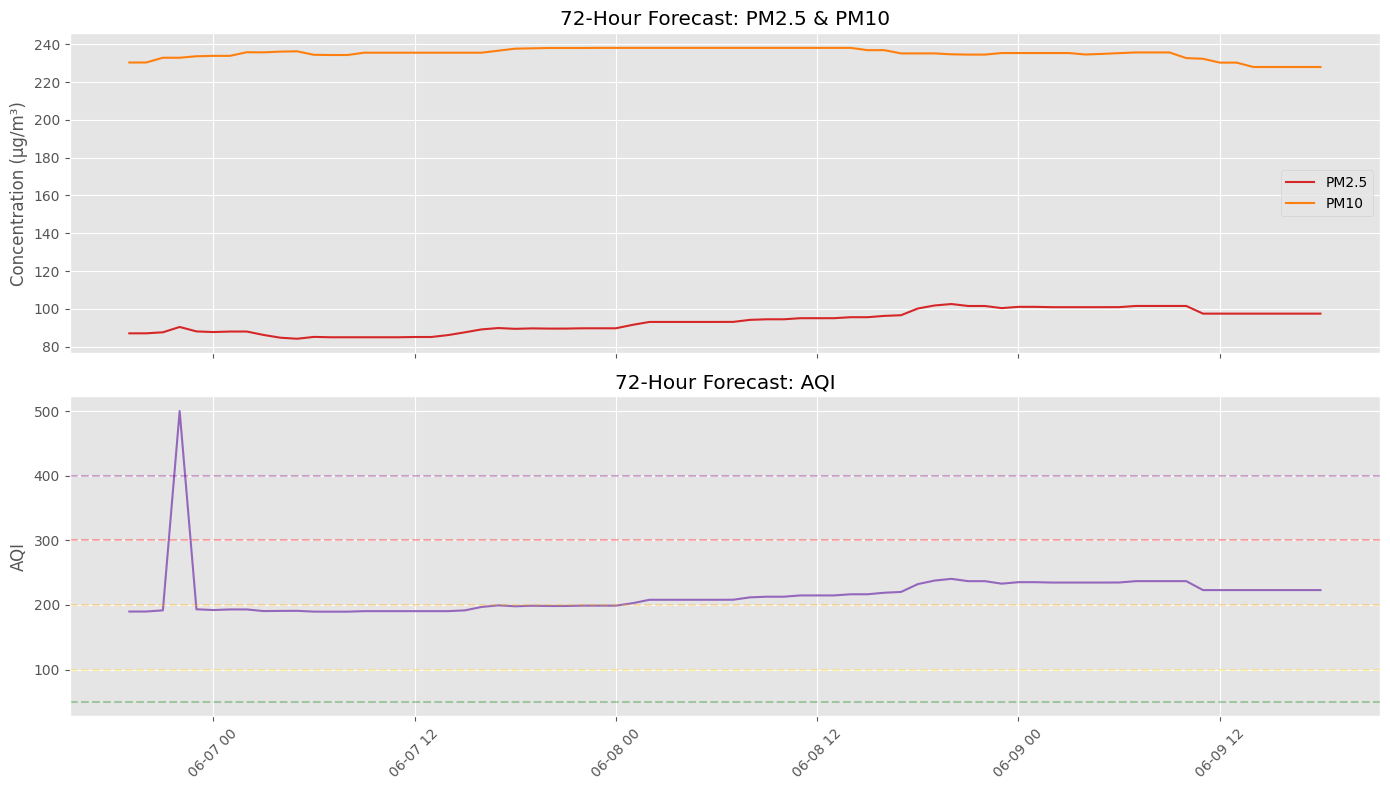

In [100]:
plt.style.use('ggplot')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(forecast_72h["datetime"], forecast_72h["pm25"], label="PM2.5", color="tab:red")
axes[0].plot(forecast_72h["datetime"], forecast_72h["pm10"], label="PM10", color="tab:orange")
axes[0].set_ylabel("Concentration (µg/m³)")
axes[0].set_title("72-Hour Forecast: PM2.5 & PM10")
axes[0].legend()

axes[1].plot(forecast_72h["datetime"], forecast_72h["aqi"], color="tab:purple")
axes[1].set_ylabel("AQI")
axes[1].set_title("72-Hour Forecast: AQI")
for level, color in [(50, "green"), (100, "gold"), (200, "orange"), (300, "red"), (400, "purple")]:
    axes[1].axhline(level, color=color, linestyle="--", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

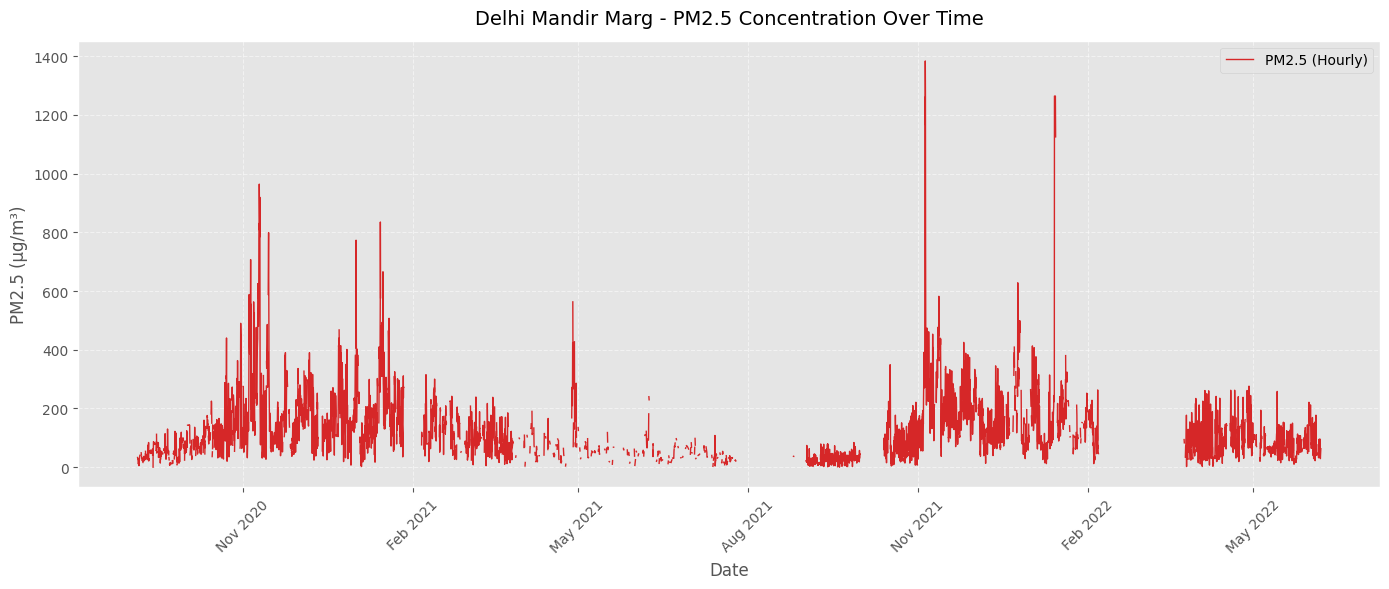

In [103]:

# Sort by datetime
merged_complete = merged_complete.sort_values('datetime')

fig, ax = plt.subplots(figsize=(14, 6))

# Plotting the interpolated PM2.5 line
ax.plot(
    merged_complete['datetime'],
    merged_complete['pm25_filled'],
    label='PM2.5 (Hourly)',
    color='#d62728',
    linewidth=1,
)

# Formatting axes
ax.set_title(
    'Delhi Mandir Marg - PM2.5 Concentration Over Time',
    fontsize=14,
    pad=12,
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()